# Experiment 2: Out-of-Distribution Classes — Rangoli and Microscopy

We introduce two classes outside ImageNet's 1000-category vocabulary and apply the same geometric diagnostics. We examine PCA geometry, distance heatmaps, Mahalanobis distance, intra-class KL divergence, and top-5 prediction distributions to assess representational coherence.

## PCA 3D — All 5 Classes

ResNet PCA 3D explained variance: 0.316
MobileNet PCA 3D explained variance: 0.256


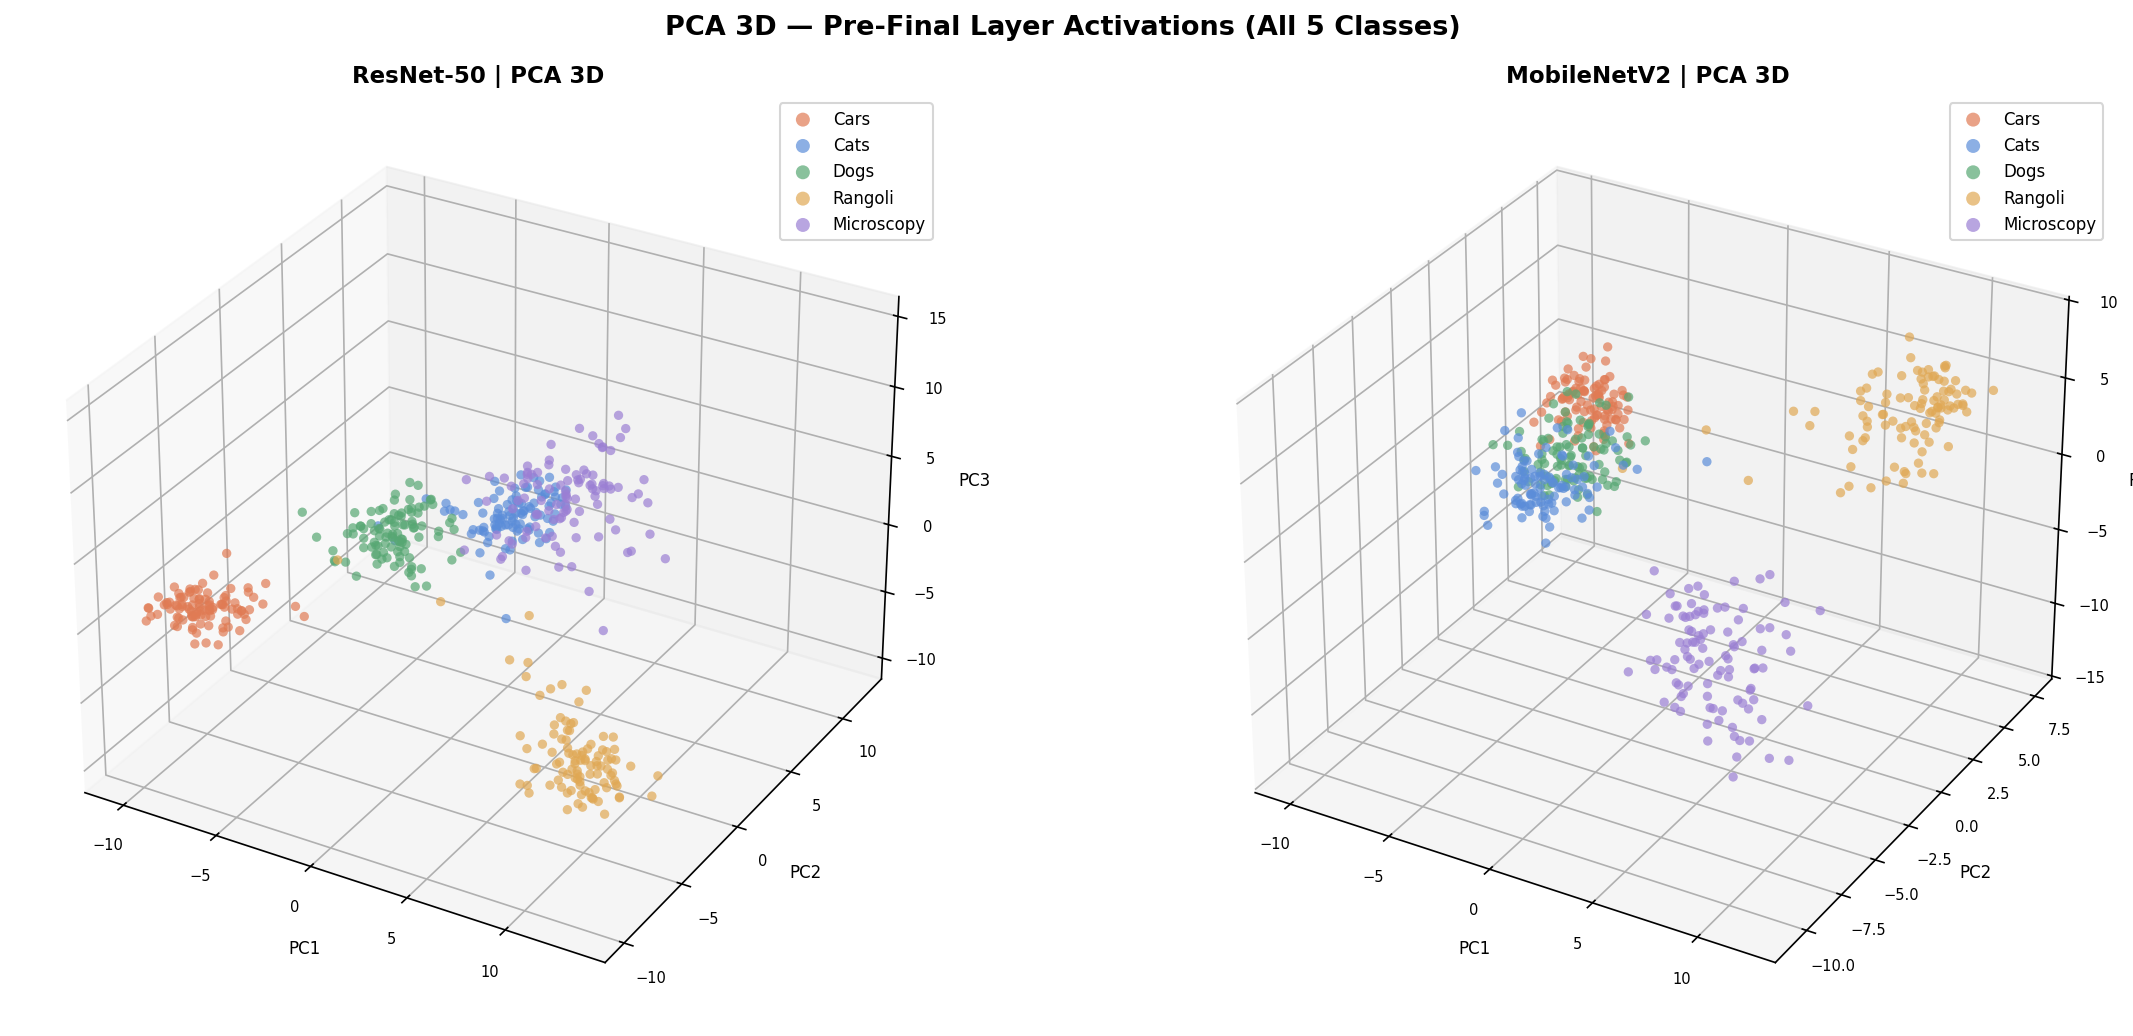

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

COLOR_MAP = {
    "Cars":       "#e07b54",
    "Cats":       "#5b8dd9",
    "Dogs":       "#57a773",
    "Rangoli":    "#e0a854",
    "Microscopy": "#9b7fd4"
}

pca3 = PCA(n_components=3)
rn_3d = pca3.fit_transform(rn_raw)
print(f"ResNet PCA 3D explained variance: {pca3.explained_variance_ratio_.sum():.3f}")

pca3 = PCA(n_components=3)
mn_3d = pca3.fit_transform(mn_raw)
print(f"MobileNet PCA 3D explained variance: {pca3.explained_variance_ratio_.sum():.3f}")

fig = plt.figure(figsize=(16, 7), dpi=150)

for idx, (coords, title) in enumerate([(rn_3d, "ResNet-50"), (mn_3d, "MobileNetV2")]):
    ax = fig.add_subplot(1, 2, idx + 1, projection='3d')

    for cls in target_classes:
        mask = labels == cls
        ax.scatter(coords[mask, 0], coords[mask, 1], coords[mask, 2],
                   label=cls, color=COLOR_MAP[cls],
                   alpha=0.7, s=20, edgecolors='none')

    ax.set_title(f"{title} | PCA 3D", fontsize=11, fontweight='bold')
    ax.set_xlabel("PC1", fontsize=8)
    ax.set_ylabel("PC2", fontsize=8)
    ax.set_zlabel("PC3", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=8, markerscale=1.5)

plt.suptitle("PCA 3D — Pre-Final Layer Activations (All 5 Classes)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Distance Heatmaps — All 5 Classes (Euclidean & Cosine)

Loaded: Cars
Loaded: Cats
Loaded: Dogs
Loaded: Rangoli
Loaded: Microscopy

ResNet features shape:    (500, 2048)
MobileNet features shape: (500, 1280)

ResNet PCA explained variance:    0.316
MobileNet PCA explained variance: 0.256

Computing distance matrices...
Done!


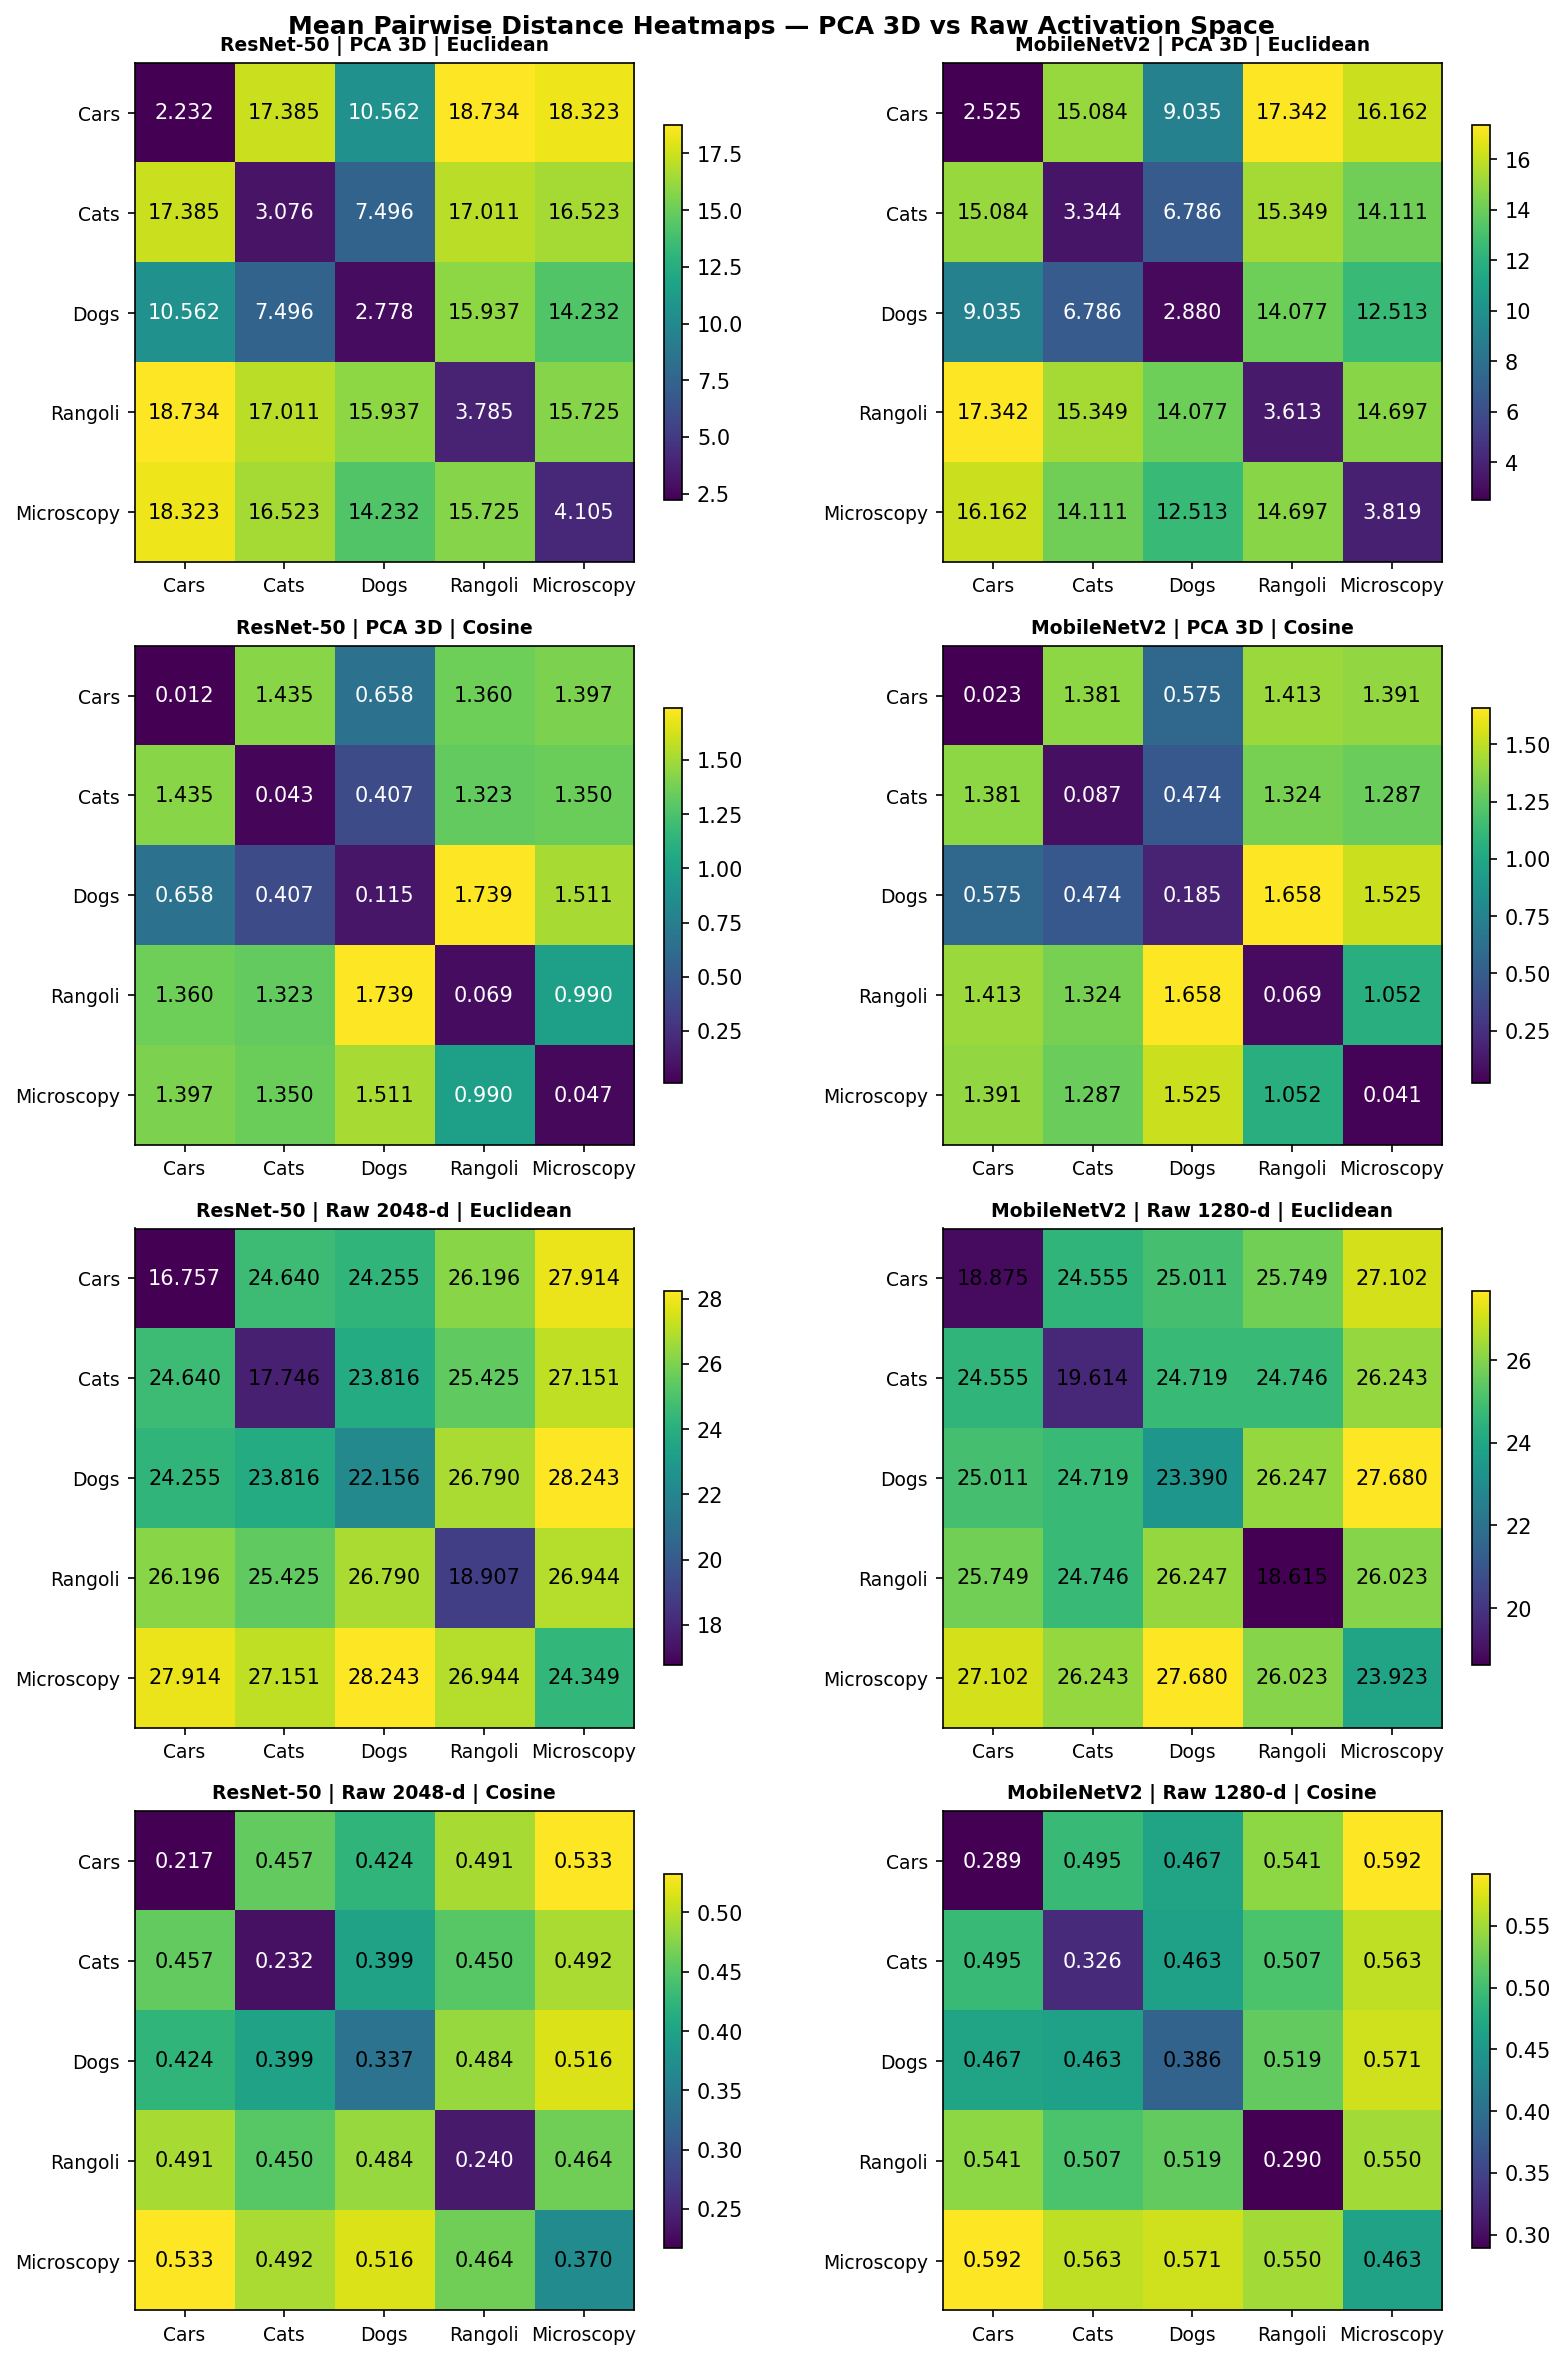

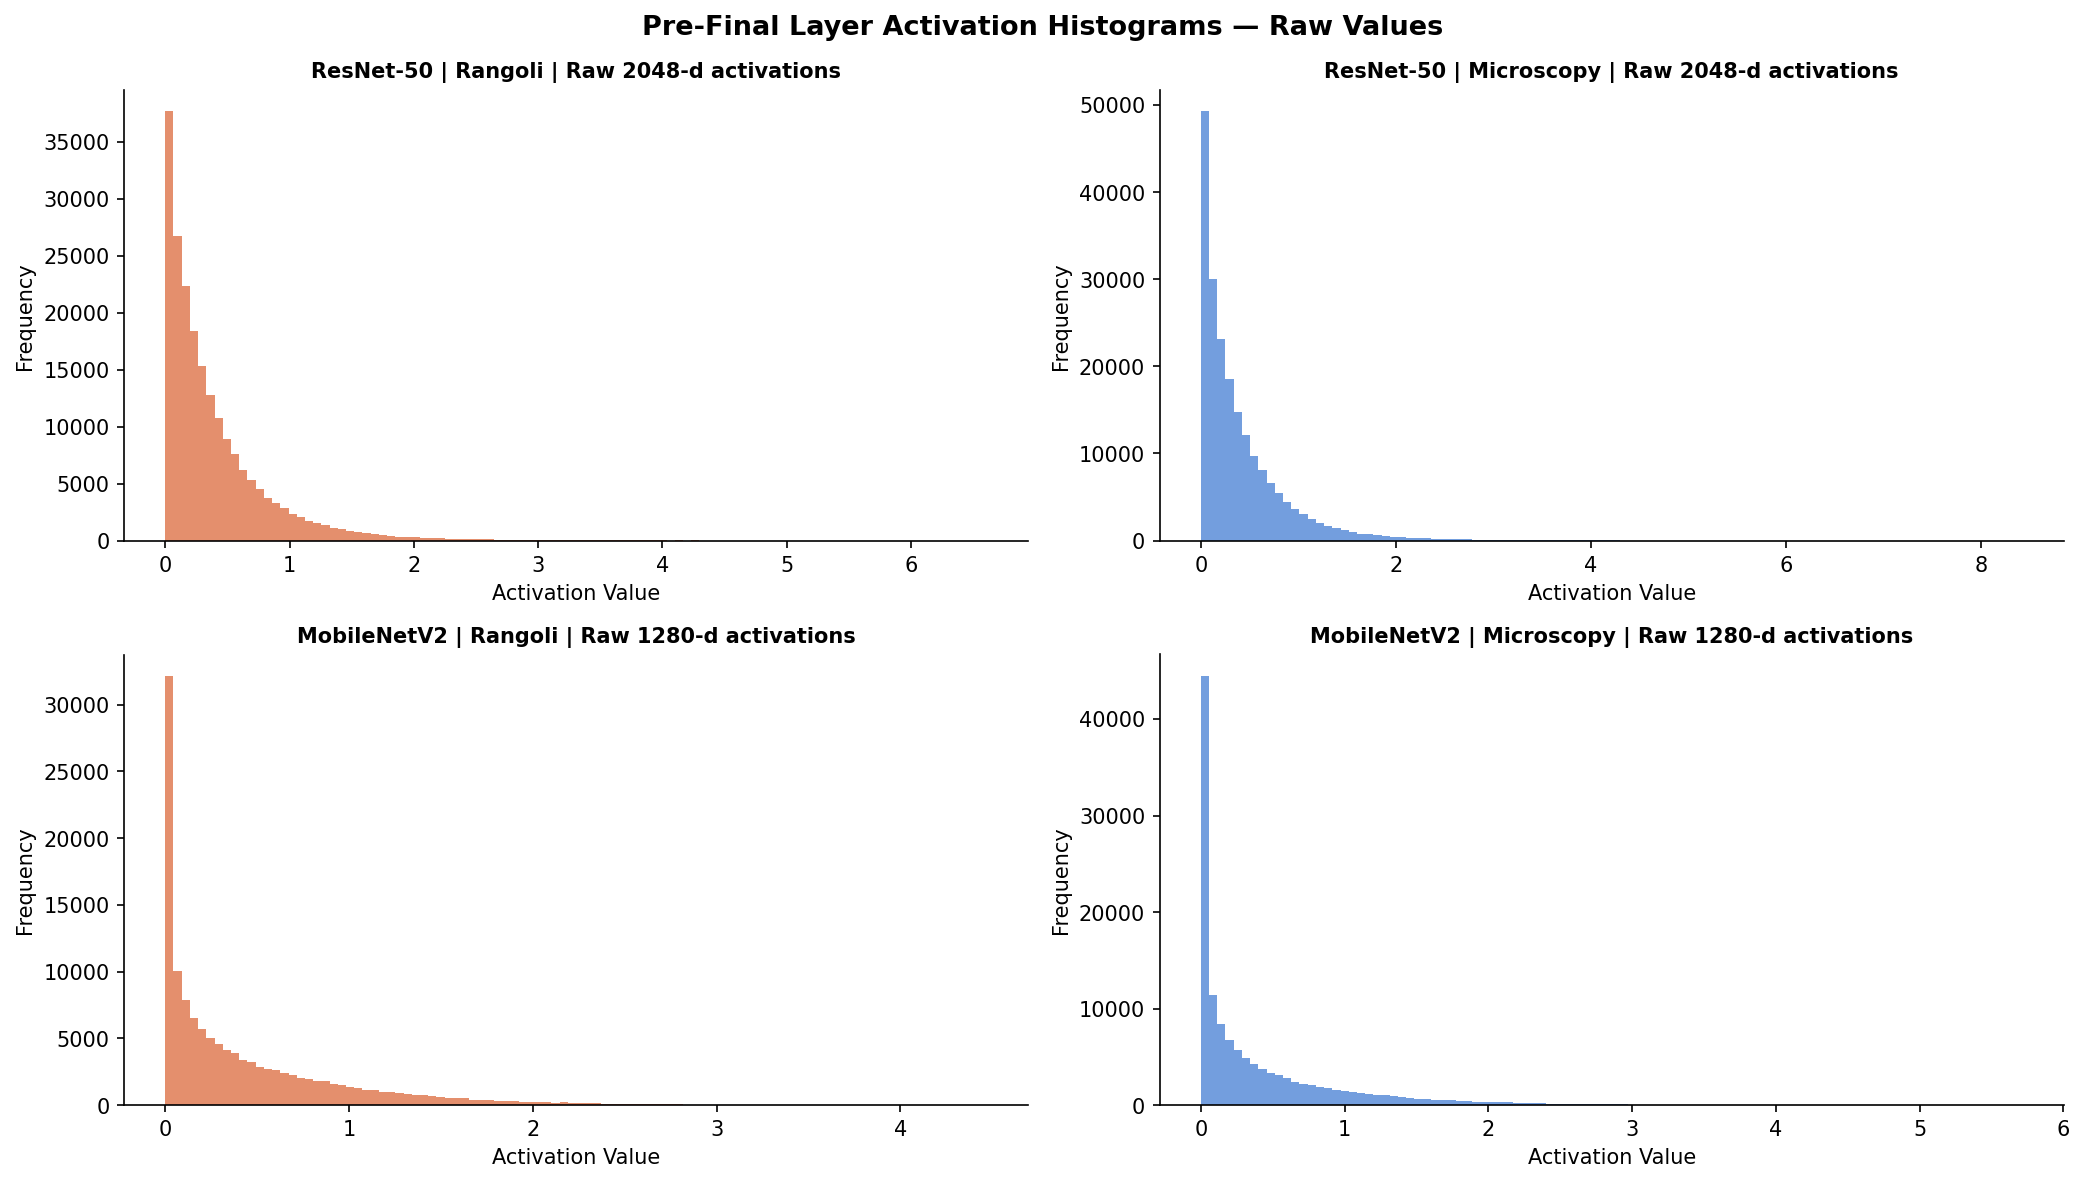

In [ ]:
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
import numpy as np
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import os
import matplotlib.pyplot as plt
import seaborn as sns

# -------- CONFIG --------
base_path = "/Users/jaeeponde/Thesis/Data_100"
target_classes = ["Cars", "Cats", "Dogs", "Rangoli", "Microscopy"]
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tiff", ".webp")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------- TRANSFORM --------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def load_image(path):
    return transform(Image.open(path).convert("RGB")).unsqueeze(0).to(device)

# -------- EXTRACTORS --------
resnet_full = models.resnet50(pretrained=True).to(device)
resnet_full.eval()
resnet_extractor = nn.Sequential(*list(resnet_full.children())[:-1])

mobilenet_full = models.mobilenet_v2(pretrained=True).to(device)
mobilenet_full.eval()
mobilenet_extractor = nn.Sequential(
    mobilenet_full.features,
    nn.AdaptiveAvgPool2d((1, 1))
)

def extract_features(extractor, img_tensor):
    with torch.no_grad():
        return extractor(img_tensor).view(-1).cpu().numpy()

# -------- LOAD FIRST 100 FROM EVERY CLASS --------
rn_raw_list = []
mn_raw_list = []
labels_list = []

for cls in target_classes:
    cls_path = os.path.join(base_path, cls)
    images = [
        os.path.join(cls_path, f)
        for f in sorted(os.listdir(cls_path))
        if f.lower().endswith(image_extensions)
    ][:100]

    for img_path in images:
        try:
            img = load_image(img_path)
            rn_raw_list.append(extract_features(resnet_extractor, img))
            mn_raw_list.append(extract_features(mobilenet_extractor, img))
            labels_list.append(cls)
        except:
            continue

    print(f"Loaded: {cls}")

rn_raw = np.array(rn_raw_list)
mn_raw = np.array(mn_raw_list)
labels = np.array(labels_list)

print(f"\nResNet features shape:    {rn_raw.shape}")
print(f"MobileNet features shape: {mn_raw.shape}")

# -------- PCA 3D --------
pca = PCA(n_components=3)
rn_prefinal_coords = pca.fit_transform(rn_raw)
print(f"\nResNet PCA explained variance:    {pca.explained_variance_ratio_.sum():.3f}")

pca = PCA(n_components=3)
mn_prefinal_coords = pca.fit_transform(mn_raw)
print(f"MobileNet PCA explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# -------- DISTANCE MATRIX BUILDER --------
def build_distance_matrix(acts, labels, classes, metric):
    n   = len(classes)
    mat = np.zeros((n, n))
    for i, cls_i in enumerate(classes):
        for j, cls_j in enumerate(classes):
            pts_i     = acts[labels == cls_i]
            pts_j     = acts[labels == cls_j]
            mat[i, j] = cdist(pts_i, pts_j, metric=metric).mean()
    return mat

# -------- COMPUTE ALL 8 MATRICES --------
print("\nComputing distance matrices...")
rn_pca_euc = build_distance_matrix(rn_prefinal_coords, labels, target_classes, 'euclidean')
rn_pca_cos = build_distance_matrix(rn_prefinal_coords, labels, target_classes, 'cosine')
mn_pca_euc = build_distance_matrix(mn_prefinal_coords, labels, target_classes, 'euclidean')
mn_pca_cos = build_distance_matrix(mn_prefinal_coords, labels, target_classes, 'cosine')

rn_raw_euc = build_distance_matrix(rn_raw, labels, target_classes, 'euclidean')
rn_raw_cos = build_distance_matrix(rn_raw, labels, target_classes, 'cosine')
mn_raw_euc = build_distance_matrix(mn_raw, labels, target_classes, 'euclidean')
mn_raw_cos = build_distance_matrix(mn_raw, labels, target_classes, 'cosine')
print("Done!")

# -------- PLOT 1: DISTANCE HEATMAPS --------
fig, axes = plt.subplots(4, 2, figsize=(11, 16), dpi=150)

plot_configs = [
    (axes[0, 0], rn_pca_euc, "ResNet-50 | PCA 3D | Euclidean"),
    (axes[0, 1], mn_pca_euc, "MobileNetV2 | PCA 3D | Euclidean"),
    (axes[1, 0], rn_pca_cos, "ResNet-50 | PCA 3D | Cosine"),
    (axes[1, 1], mn_pca_cos, "MobileNetV2 | PCA 3D | Cosine"),
    (axes[2, 0], rn_raw_euc, "ResNet-50 | Raw 2048-d | Euclidean"),
    (axes[2, 1], mn_raw_euc, "MobileNetV2 | Raw 1280-d | Euclidean"),
    (axes[3, 0], rn_raw_cos, "ResNet-50 | Raw 2048-d | Cosine"),
    (axes[3, 1], mn_raw_cos, "MobileNetV2 | Raw 1280-d | Cosine"),
]

for ax, mat, title in plot_configs:
    im = ax.imshow(mat, cmap='viridis')
    for i in range(len(target_classes)):
        for j in range(len(target_classes)):
            ax.text(j, i, f"{mat[i, j]:.3f}",
                    ha='center', va='center', fontsize=10,
                    color='white' if mat[i, j] < mat.max() * 0.6 else 'black')
    ax.set_xticks(range(len(target_classes)))
    ax.set_yticks(range(len(target_classes)))
    ax.set_xticklabels(target_classes, fontsize=9)
    ax.set_yticklabels(target_classes, fontsize=9)
    ax.set_title(title, fontsize=9, fontweight='bold')
    fig.colorbar(im, ax=ax, shrink=0.75, pad=0.04)

plt.suptitle("Mean Pairwise Distance Heatmaps — PCA 3D vs Raw Activation Space",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("distance_heatmaps_pca_raw.png", dpi=150, bbox_inches='tight')
plt.show()

# -------- PLOT 2: ACTIVATION HISTOGRAMS --------
classes_to_plot = ["Rangoli", "Microscopy"]
colors = {"Rangoli": "#e07b54", "Microscopy": "#5b8dd9"}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), dpi=150)

for col, cls in enumerate(classes_to_plot):
    cls_mask = labels == cls

    rn_cls = rn_raw[cls_mask].flatten()
    mn_cls = mn_raw[cls_mask].flatten()

    axes[0, col].hist(rn_cls, bins=100, color=colors[cls], alpha=0.85, edgecolor='none')
    axes[0, col].set_title(f"ResNet-50 | {cls} | Raw 2048-d activations", fontsize=10, fontweight='bold')
    axes[0, col].set_xlabel("Activation Value")
    axes[0, col].set_ylabel("Frequency")
    sns.despine(ax=axes[0, col])

    axes[1, col].hist(mn_cls, bins=100, color=colors[cls], alpha=0.85, edgecolor='none')
    axes[1, col].set_title(f"MobileNetV2 | {cls} | Raw 1280-d activations", fontsize=10, fontweight='bold')
    axes[1, col].set_xlabel("Activation Value")
    axes[1, col].set_ylabel("Frequency")
    sns.despine(ax=axes[1, col])

plt.suptitle("Pre-Final Layer Activation Histograms — Raw Values", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("activation_histograms.png", dpi=150, bbox_inches='tight')
plt.show()

## Mahalanobis Distance — All 5 Classes

In [48]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import torch
import torchvision.transforms as transforms
import torchvision.models as models
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [49]:
def load_images_from_folder(folder_path, n=100, img_size=224):
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    images = []
    valid_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp')
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(valid_exts)][:n]
    
    for fname in files:
        try:
            img = Image.open(os.path.join(folder_path, fname)).convert('RGB')
            images.append(transform(img))
        except Exception as e:
            print(f"Skipping {fname}: {e}")
    
    print(f"Loaded {len(images)} images from {folder_path}")
    return torch.stack(images) if images else None

In [50]:
def build_resnet_with_hook():
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    model.eval().to(device)
    activations = {}

    def hook_fn(module, input, output):
        activations['pre_final'] = output.detach().cpu().numpy()

    # Hook on avgpool (pre-final layer, before the FC head)
    model.avgpool.register_forward_hook(hook_fn)
    return model, activations

def build_mobilenet_with_hook():
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    model.eval().to(device)
    activations = {}

    def hook_fn(module, input, output):
        activations['pre_final'] = output.detach().cpu().numpy()

    # Hook on the adaptive avg pool (pre-final layer)
    model.features.register_forward_hook(hook_fn)
    return model, activations

resnet_model, resnet_acts = build_resnet_with_hook()
mobilenet_model, mobilenet_acts = build_mobilenet_with_hook()
print("Models ready.")

Models ready.


In [51]:
def extract_activations(model, activations_dict, image_tensor, batch_size=16):
    all_acts = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(image_tensor), batch_size):
            batch = image_tensor[i:i+batch_size].to(device)
            _ = model(batch)
            act = activations_dict['pre_final']
            # Flatten spatial dims if needed
            act = act.reshape(act.shape[0], -1)
            all_acts.append(act)
    return np.vstack(all_acts)

In [52]:
DATA_ROOT = "/Users/jaeeponde/Thesis/Data_100"  # <-- adjust path if needed
data_folders = {
    "Cats":        os.path.join(DATA_ROOT, "Cats"),
    "Dogs":        os.path.join(DATA_ROOT, "Dogs"),
    "Cars":        os.path.join(DATA_ROOT, "Cars"),
    "Rangoli":     os.path.join(DATA_ROOT, "Rangoli"),
    "Microscopy":  os.path.join(DATA_ROOT, "Microscopy"),
}

data_tensors = {}
for name, path in data_folders.items():
    data_tensors[name] = load_images_from_folder(path, n=200)

Loaded 200 images from /Users/jaeeponde/Thesis/Data_100/Cats
Loaded 200 images from /Users/jaeeponde/Thesis/Data_100/Dogs
Loaded 200 images from /Users/jaeeponde/Thesis/Data_100/Cars
Loaded 200 images from /Users/jaeeponde/Thesis/Data_100/Rangoli
Loaded 200 images from /Users/jaeeponde/Thesis/Data_100/Microscopy


In [53]:
POSE_ROOT = "/Users/jaeeponde/Thesis/Data/All_images/Pose_100"  # <-- adjust path if needed
pose_folders = {
    "Sleeping": os.path.join(POSE_ROOT, "sleeping"),
    "Standing": os.path.join(POSE_ROOT, "standing"),
}

pose_tensors = {}
for name, path in pose_folders.items():
    pose_tensors[name] = load_images_from_folder(path, n=100)

Loaded 100 images from /Users/jaeeponde/Thesis/Data/All_images/Pose_100/sleeping
Loaded 100 images from /Users/jaeeponde/Thesis/Data/All_images/Pose_100/standing


In [54]:
# Data_100 activations
resnet_data_acts  = {}
mobilenet_data_acts = {}

for name, tensor in data_tensors.items():
    if tensor is not None:
        print(f"Extracting ResNet  activations: {name}")
        resnet_data_acts[name]    = extract_activations(resnet_model,    resnet_acts,    tensor)
        print(f"Extracting MobileNet activations: {name}")
        mobilenet_data_acts[name] = extract_activations(mobilenet_model, mobilenet_acts, tensor)

# Pose_100 activations (ResNet only for bar plot 5 & 6, but we'll do both)
resnet_pose_acts    = {}
mobilenet_pose_acts = {}

for name, tensor in pose_tensors.items():
    if tensor is not None:
        print(f"Extracting ResNet  activations: {name}")
        resnet_pose_acts[name]    = extract_activations(resnet_model,    resnet_acts,    tensor)
        print(f"Extracting MobileNet activations: {name}")
        mobilenet_pose_acts[name] = extract_activations(mobilenet_model, mobilenet_acts, tensor)

print("All activations extracted!")

Extracting ResNet  activations: Cats
Extracting MobileNet activations: Cats
Extracting ResNet  activations: Dogs
Extracting MobileNet activations: Dogs
Extracting ResNet  activations: Cars
Extracting MobileNet activations: Cars
Extracting ResNet  activations: Rangoli
Extracting MobileNet activations: Rangoli
Extracting ResNet  activations: Microscopy
Extracting MobileNet activations: Microscopy
Extracting ResNet  activations: Sleeping
Extracting MobileNet activations: Sleeping
Extracting ResNet  activations: Standing
Extracting MobileNet activations: Standing
All activations extracted!


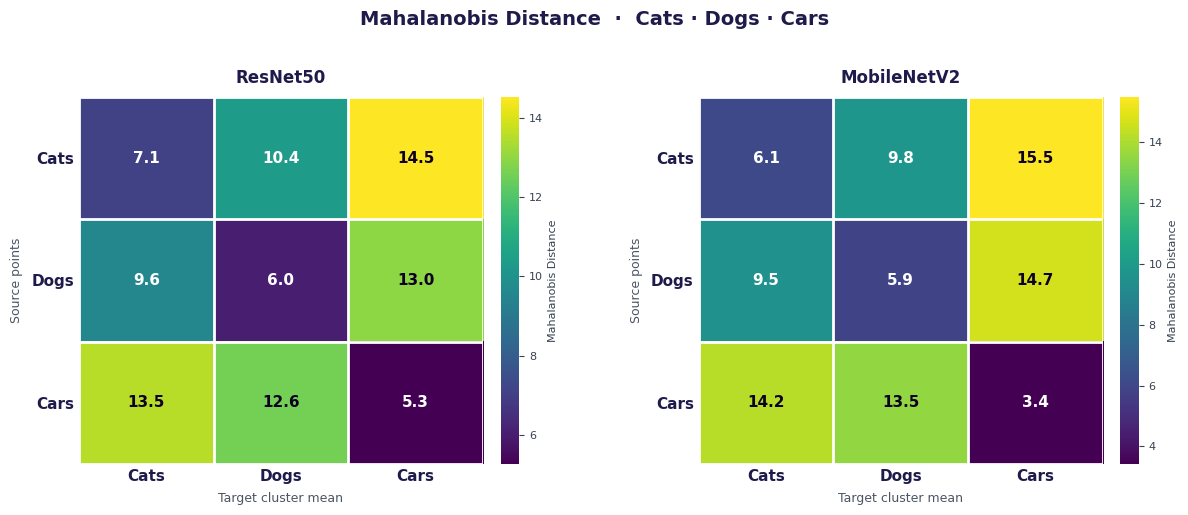

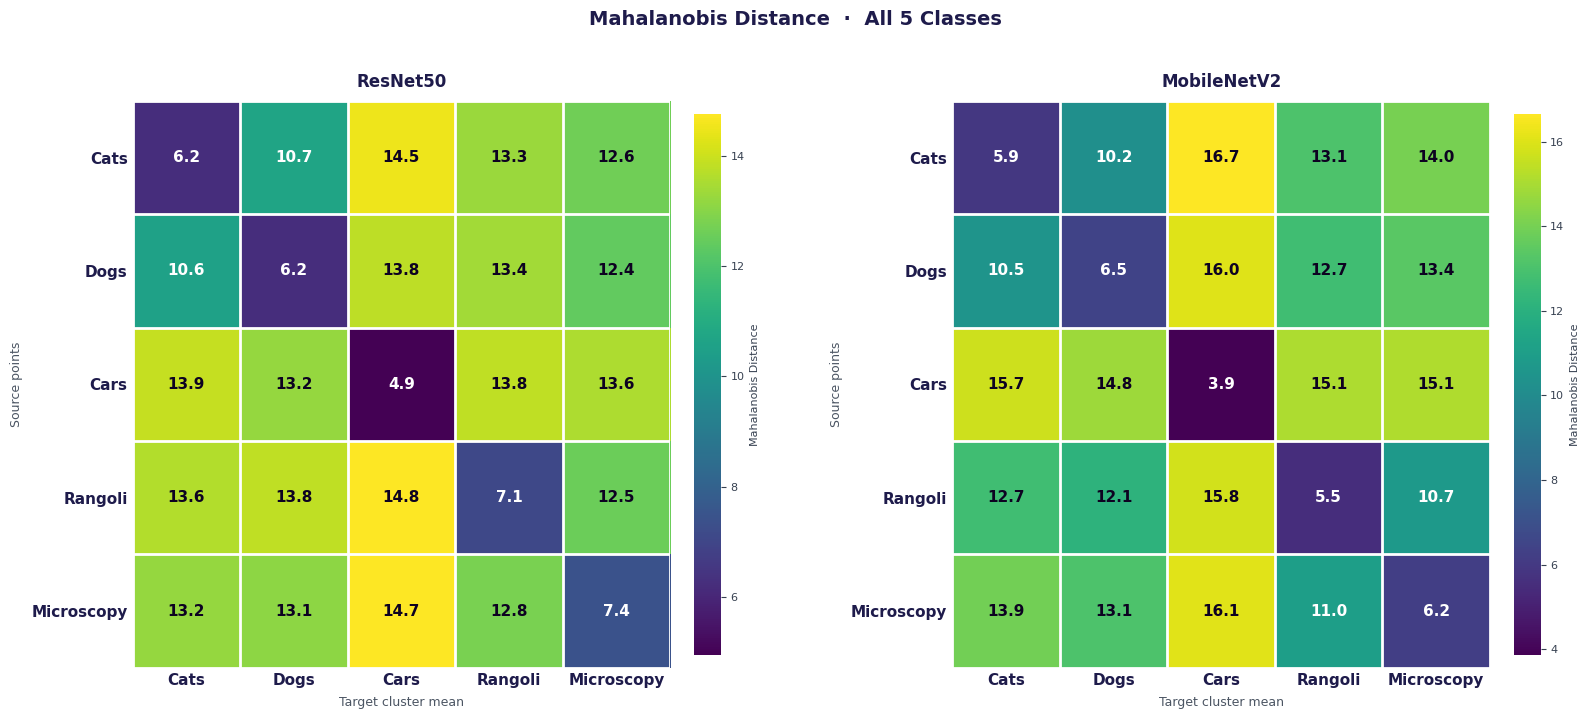

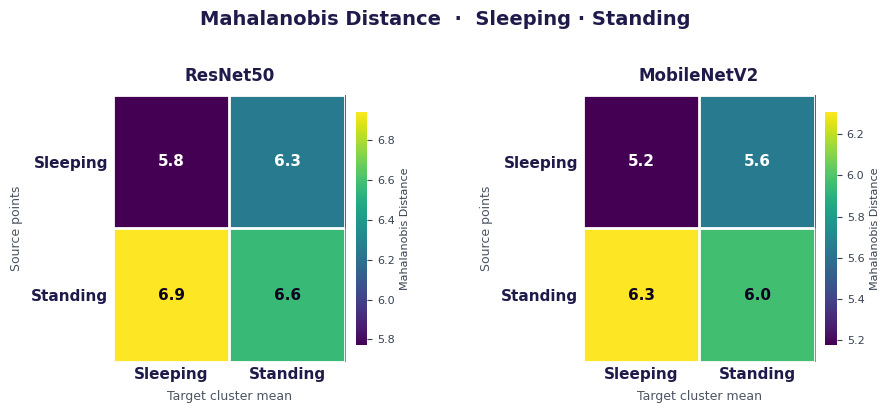

Saved → mahal1_cats_dogs_cars.png
        mahal2_all5.png
        mahal3_pose.png


In [64]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial.distance import mahalanobis

def pointwise_mahal_matrix(acts_dict, keys, n_components=50):
    X_all = np.vstack([acts_dict[k] for k in keys])
    X_all = StandardScaler().fit_transform(X_all)
    n_comp = min(n_components, X_all.shape[0] - 1, X_all.shape[1])
    X_all  = PCA(n_components=n_comp).fit_transform(X_all)

    normed, idx = {}, 0
    for k in keys:
        n = len(acts_dict[k])
        normed[k] = X_all[idx:idx+n]
        idx += n

    n_total = len(X_all)
    pooled_cov = sum(
        np.cov(normed[k].T) * (len(normed[k]) - 1) for k in keys
    ) / (n_total - len(keys))
    pooled_cov += np.eye(pooled_cov.shape[0]) * 1e-6
    VI = np.linalg.inv(pooled_cov)

    n = len(keys)
    D = np.zeros((n, n))
    for i, src in enumerate(keys):
        for j, tgt in enumerate(keys):
            mu_tgt = normed[tgt].mean(axis=0)
            D[i, j] = np.mean([mahalanobis(x, mu_tgt, VI) for x in normed[src]])
    return D


def plot_mahal(ax, D, keys, title):
    n = len(keys)

    im = ax.imshow(D, cmap='viridis', aspect='auto',
                   vmin=D.min(), vmax=D.max(), interpolation='nearest')

    # Annotate every cell
    vrange = D.max() - D.min()
    for i in range(n):
        for j in range(n):
            val      = D[i, j]
            norm_val = (val - D.min()) / (vrange + 1e-9)
            color    = 'white' if norm_val < 0.6 else '#0d0221'
            ax.text(j, i, f"{val:.1f}",
                    ha='center', va='center',
                    fontsize=11, fontweight='bold', color=color)

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(keys, fontsize=11, color='#1e1b4b', fontweight='semibold')
    ax.set_yticklabels(keys, fontsize=11, color='#1e1b4b', fontweight='semibold')
    ax.tick_params(length=0)
    ax.set_xlabel("Target cluster mean", fontsize=9, color='#4b5563', labelpad=6)
    ax.set_ylabel("Source points",       fontsize=9, color='#4b5563', labelpad=6)
    ax.set_title(title, fontsize=12, fontweight='bold', color='#1e1b4b', pad=10)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8, colors='#374151')
    cbar.set_label("Mahalanobis Distance", fontsize=8, color='#374151')
    cbar.outline.set_linewidth(0)

    # Clean cell borders
    for x in np.arange(-0.5, n, 1):
        ax.axhline(x, color='white', linewidth=2)
        ax.axvline(x, color='white', linewidth=2)

    for spine in ax.spines.values():
        spine.set_visible(False)


# ── Group definitions ──────────────────────────────────────────────────────
cats_dogs_cars = ["Cats", "Dogs", "Cars"]
all_five       = ["Cats", "Dogs", "Cars", "Rangoli", "Microscopy"]
pose_classes   = ["Sleeping", "Standing"]

SAVE_KW = dict(dpi=200, bbox_inches='tight', facecolor='white')

# ── Plot 1 : Cats · Dogs · Cars ───────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('white')
fig.suptitle("Mahalanobis Distance  ·  Cats · Dogs · Cars",
             fontsize=14, fontweight='bold', color='#1e1b4b', y=1.02)
plot_mahal(ax1, pointwise_mahal_matrix(resnet_data_acts,    cats_dogs_cars), cats_dogs_cars, "ResNet50")
plot_mahal(ax2, pointwise_mahal_matrix(mobilenet_data_acts, cats_dogs_cars), cats_dogs_cars, "MobileNetV2")
fig.tight_layout(w_pad=5)
fig.savefig("mahal1_cats_dogs_cars.png", **SAVE_KW)

# ── Plot 2 : All 5 Classes ─────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')
fig.suptitle("Mahalanobis Distance  ·  All 5 Classes",
             fontsize=14, fontweight='bold', color='#1e1b4b', y=1.02)
plot_mahal(ax1, pointwise_mahal_matrix(resnet_data_acts,    all_five), all_five, "ResNet50")
plot_mahal(ax2, pointwise_mahal_matrix(mobilenet_data_acts, all_five), all_five, "MobileNetV2")
fig.tight_layout(w_pad=5)
fig.savefig("mahal2_all5.png", **SAVE_KW)

# ── Plot 3 : Sleeping · Standing ──────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))
fig.patch.set_facecolor('white')
fig.suptitle("Mahalanobis Distance  ·  Sleeping · Standing",
             fontsize=14, fontweight='bold', color='#1e1b4b', y=1.02)
plot_mahal(ax1, pointwise_mahal_matrix(resnet_pose_acts,    pose_classes), pose_classes, "ResNet50")
plot_mahal(ax2, pointwise_mahal_matrix(mobilenet_pose_acts, pose_classes), pose_classes, "MobileNetV2")
fig.tight_layout(w_pad=5)
fig.savefig("mahal3_pose.png", **SAVE_KW)

plt.show()
print("Saved → mahal1_cats_dogs_cars.png")
print("        mahal2_all5.png")
print("        mahal3_pose.png")

## Intra-Class KL Divergence and Top-5 Predictions — Rangoli and Microscopy

Loading ImageNet labels...
Loading models...


/Users/jaeeponde/anaconda3/envs/kcdha/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/jaeeponde/anaconda3/envs/kcdha/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/Users/jaeeponde/anaconda3/envs/kcdha/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`

Models ready.

=== EXPERIMENT 1: Top-5 ImageNet Predictions ===


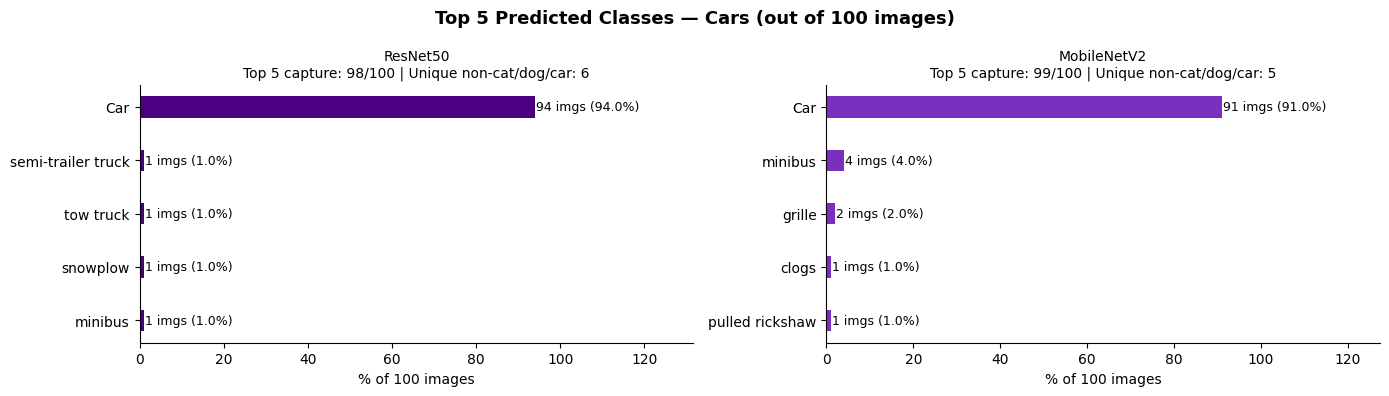


--- Cars | ResNet50 --- Top5: 98/100 | Unique: 6
  Car: 94 (94.0%)
  semi-trailer truck: 1 (1.0%)
  tow truck: 1 (1.0%)
  snowplow: 1 (1.0%)
  minibus: 1 (1.0%)

--- Cars | MobileNetV2 --- Top5: 99/100 | Unique: 5
  Car: 91 (91.0%)
  minibus: 4 (4.0%)
  grille: 2 (2.0%)
  clogs: 1 (1.0%)
  pulled rickshaw: 1 (1.0%)


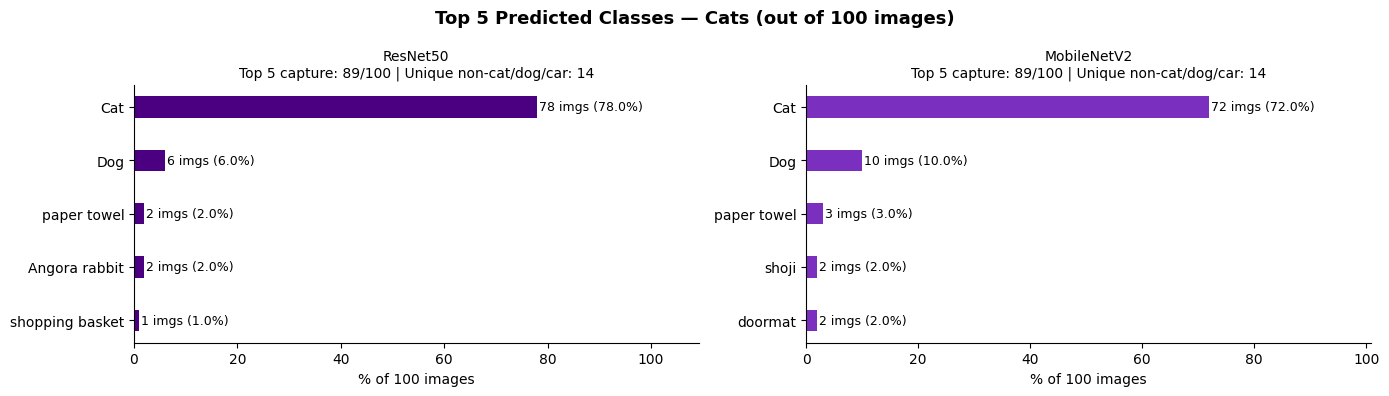


--- Cats | ResNet50 --- Top5: 89/100 | Unique: 14
  Cat: 78 (78.0%)
  Dog: 6 (6.0%)
  paper towel: 2 (2.0%)
  Angora rabbit: 2 (2.0%)
  shopping basket: 1 (1.0%)

--- Cats | MobileNetV2 --- Top5: 89/100 | Unique: 14
  Cat: 72 (72.0%)
  Dog: 10 (10.0%)
  paper towel: 3 (3.0%)
  shoji: 2 (2.0%)
  doormat: 2 (2.0%)


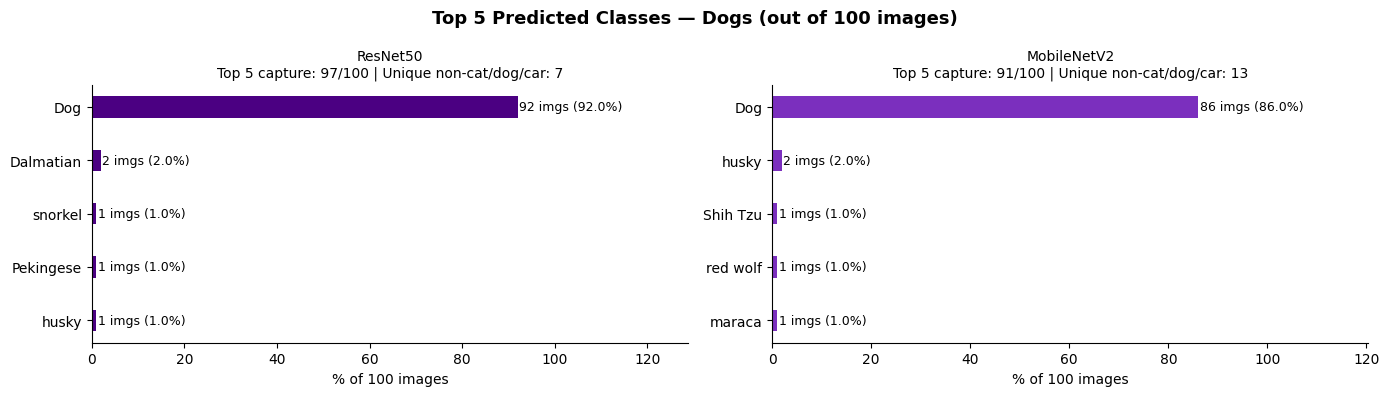


--- Dogs | ResNet50 --- Top5: 97/100 | Unique: 7
  Dog: 92 (92.0%)
  Dalmatian: 2 (2.0%)
  snorkel: 1 (1.0%)
  Pekingese: 1 (1.0%)
  husky: 1 (1.0%)

--- Dogs | MobileNetV2 --- Top5: 91/100 | Unique: 13
  Dog: 86 (86.0%)
  husky: 2 (2.0%)
  Shih Tzu: 1 (1.0%)
  red wolf: 1 (1.0%)
  maraca: 1 (1.0%)


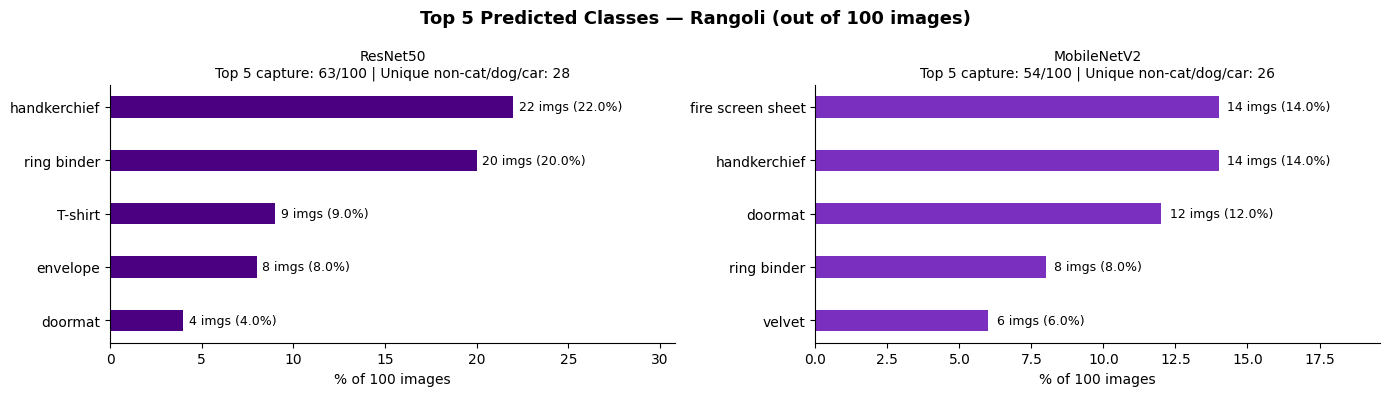


--- Rangoli | ResNet50 --- Top5: 63/100 | Unique: 28
  handkerchief: 22 (22.0%)
  ring binder: 20 (20.0%)
  T-shirt: 9 (9.0%)
  envelope: 8 (8.0%)
  doormat: 4 (4.0%)

--- Rangoli | MobileNetV2 --- Top5: 54/100 | Unique: 26
  fire screen sheet: 14 (14.0%)
  handkerchief: 14 (14.0%)
  doormat: 12 (12.0%)
  ring binder: 8 (8.0%)
  velvet: 6 (6.0%)


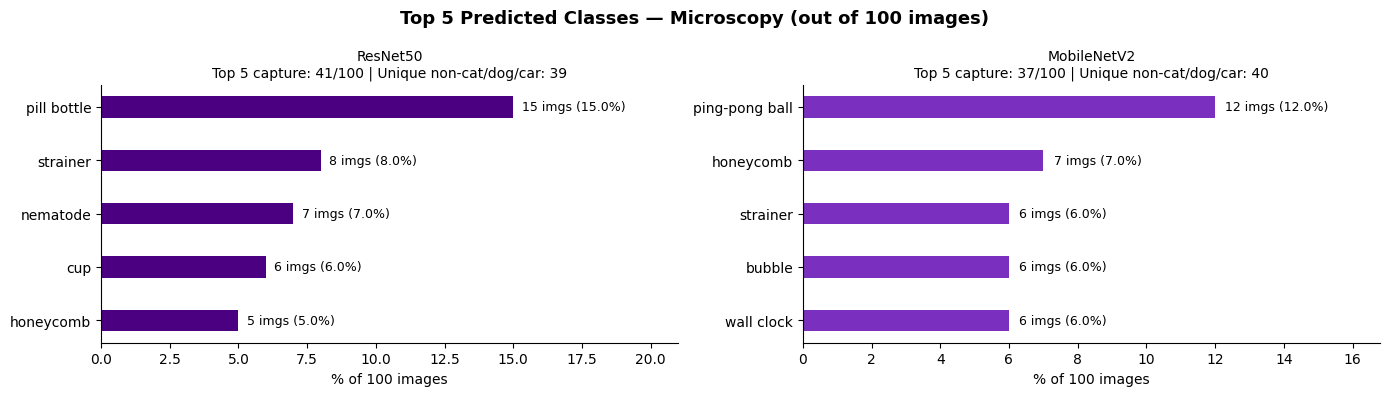


--- Microscopy | ResNet50 --- Top5: 41/100 | Unique: 39
  pill bottle: 15 (15.0%)
  strainer: 8 (8.0%)
  nematode: 7 (7.0%)
  cup: 6 (6.0%)
  honeycomb: 5 (5.0%)

--- Microscopy | MobileNetV2 --- Top5: 37/100 | Unique: 40
  ping-pong ball: 12 (12.0%)
  honeycomb: 7 (7.0%)
  strainer: 6 (6.0%)
  bubble: 6 (6.0%)
  wall clock: 6 (6.0%)

=== Loading features for Histograms + PCA ===
  Loaded: Cars
  Loaded: Cats
  Loaded: Dogs
  Loaded: Rangoli
  Loaded: Microscopy

=== EXPERIMENT 2: Activation Histograms ===


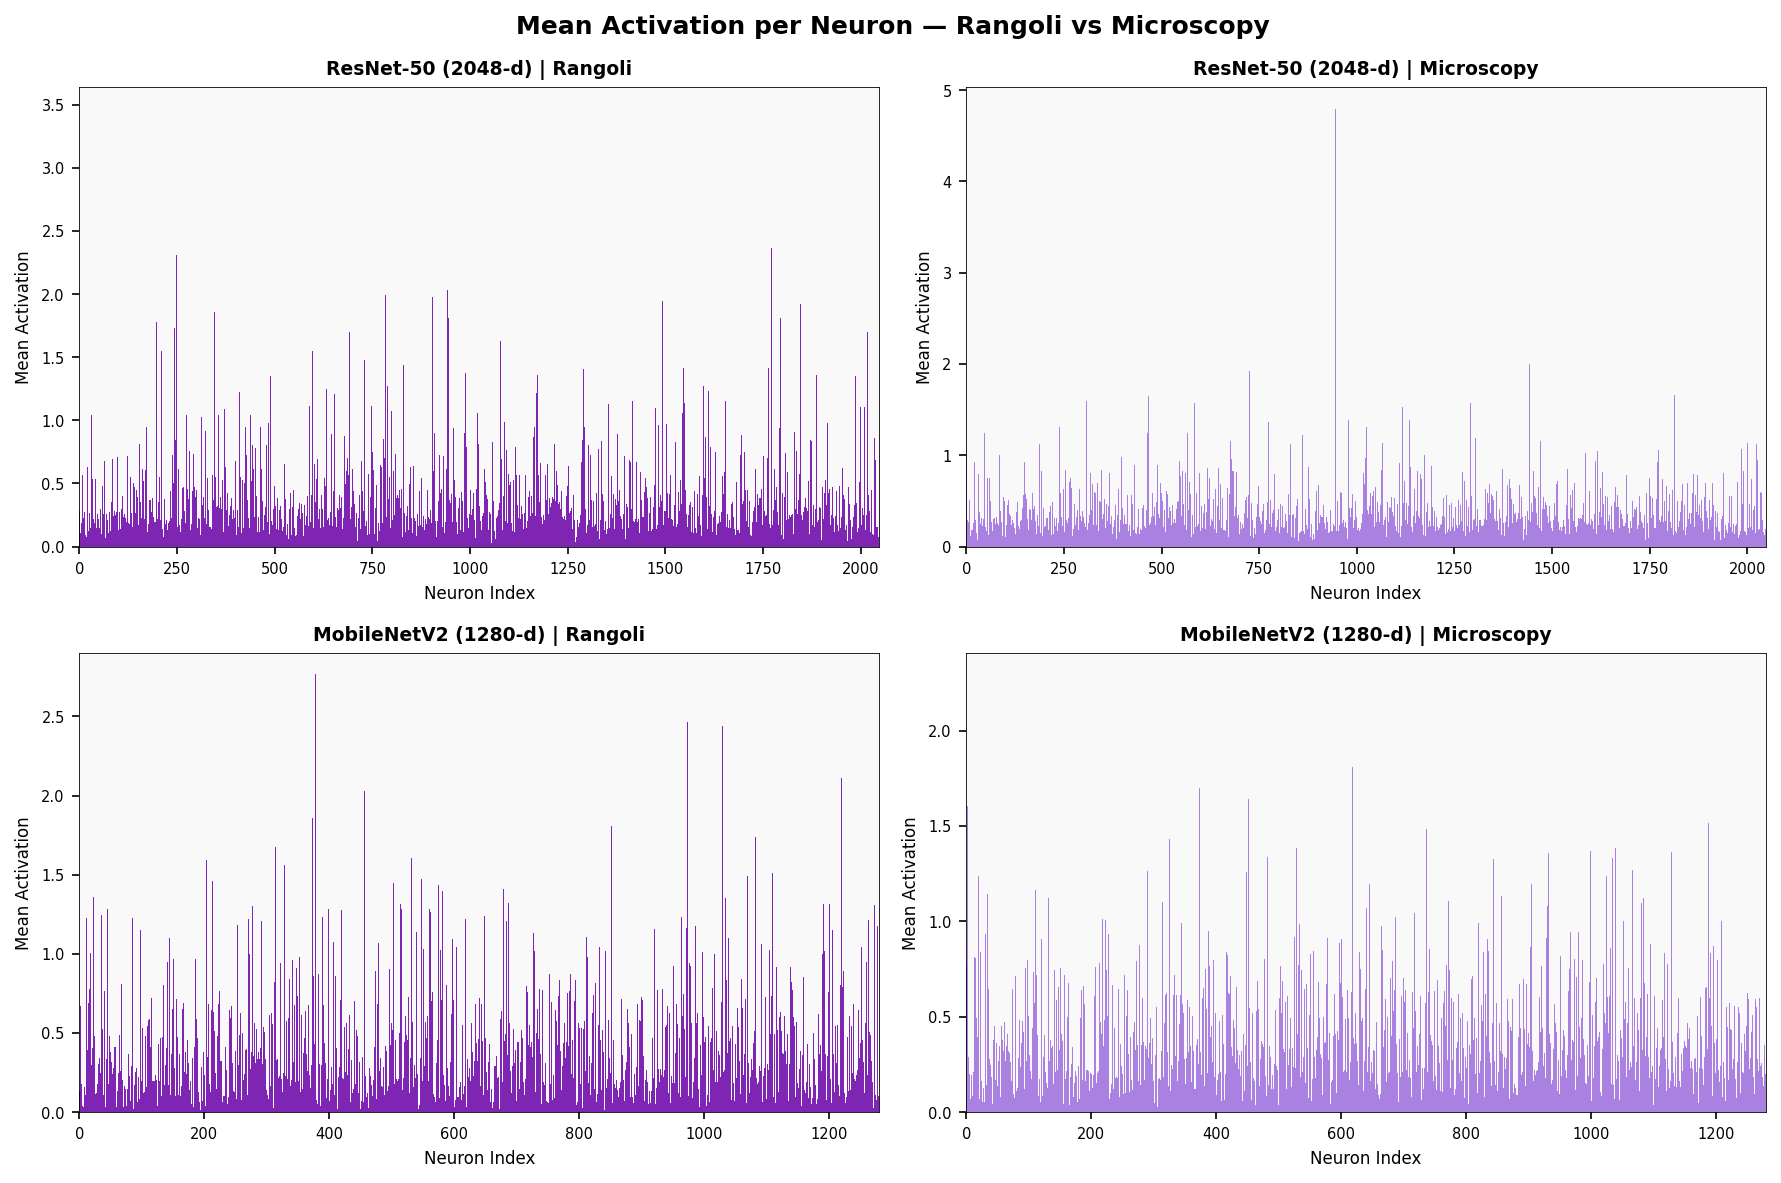


=== EXPERIMENT 3: PCA 3D ===
ResNet PCA 3D explained variance: 0.316
MobileNet PCA 3D explained variance: 0.256


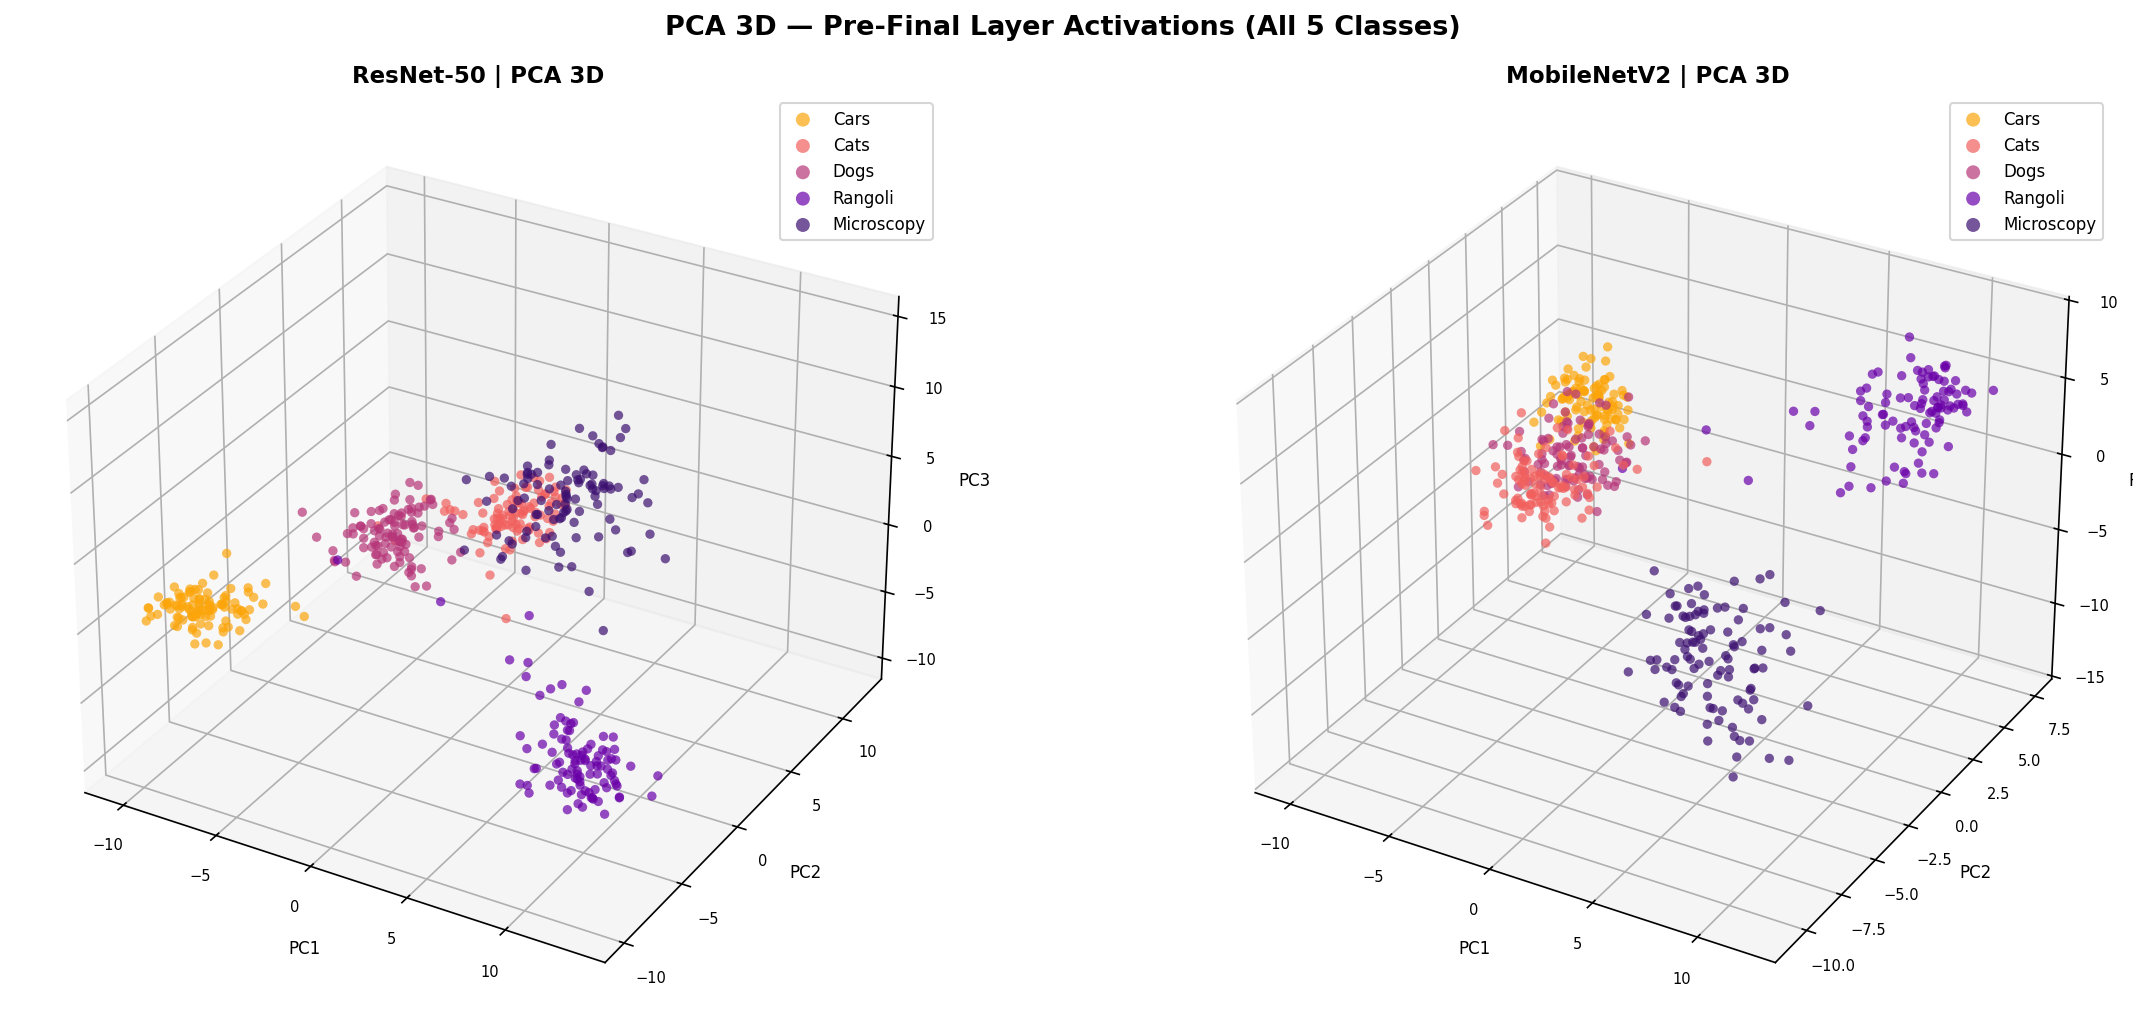


✅ All done!


In [25]:
import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import urllib
import json
from sklearn.decomposition import PCA
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D

# -------- CONFIG --------
base_path = "/Users/jaeeponde/Thesis/Data_100"
target_classes = ["Cars", "Cats", "Dogs", "Rangoli", "Microscopy"]
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tiff", ".webp")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------- COLORS --------
# magma for PCA 3D
COLOR_MAP_MAGMA = {
    "Cars":       "#FCA50A",
    "Cats":       "#F1605D",
    "Dogs":       "#B63679",
    "Rangoli":    "#6A00A8",
    "Microscopy": "#3B0F70"
}
# indigo/purple for histograms
HIST_COLORS = {
    "Rangoli":    "#6A00A8",
    "Microscopy": "#9C6CDC"
}

# -------- TRANSFORM --------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def load_image(path):
    return transform(Image.open(path).convert("RGB")).unsqueeze(0).to(device)

# -------- IMAGENET LABELS --------
print("Loading ImageNet labels...")
with urllib.request.urlopen(
    "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
) as f:
    imagenet_labels = json.load(f)

# -------- MODELS --------
print("Loading models...")
resnet = models.resnet50(pretrained=True).to(device)
resnet.eval()
resnet_extractor = nn.Sequential(*list(resnet.children())[:-1])

mobilenet = models.mobilenet_v2(pretrained=True).to(device)
mobilenet.eval()
mobilenet_extractor = nn.Sequential(
    mobilenet.features,
    nn.AdaptiveAvgPool2d((1, 1))
)
print("Models ready.\n")

def extract_features(extractor, img_tensor):
    with torch.no_grad():
        return extractor(img_tensor).view(-1).cpu().numpy()

# -------- GROUPING --------
dog_keywords = [
    "affenpinscher", "afghan hound", "airedale", "akita", "alsatian",
    "american staffordshire terrier", "appenzeller", "australian terrier",
    "basenji", "basset", "beagle", "bedlington terrier", "bernese mountain dog",
    "blenheim spaniel", "bloodhound", "bluetick", "border collie", "border terrier",
    "borzoi", "boston bull", "bouvier des flandres", "boxer", "brabancon griffon",
    "briard", "brittany spaniel", "bull mastiff", "cairn", "cardigan",
    "chesapeake bay retriever", "chihuahua", "chow", "clumber", "cocker spaniel",
    "collie", "curly-coated retriever", "dandie dinmont", "dhole", "dingo",
    "doberman", "english foxhound", "english setter", "english springer",
    "entlebucher", "eskimo dog", "flat-coated retriever", "french bulldog",
    "german shepherd", "german short-haired pointer", "giant schnauzer",
    "golden retriever", "gordon setter", "great dane", "great pyrenees",
    "greater swiss mountain dog", "groenendael", "ibizan hound", "irish setter",
    "irish terrier", "irish water spaniel", "irish wolfhound", "italian greyhound",
    "japanese spaniel", "keeshond", "kelpie", "kerry blue terrier", "komondor",
    "kuvasz", "labrador retriever", "lakeland terrier", "leonberg", "lhasa",
    "malamute", "malinois", "maltese dog", "mexican hairless", "miniature pinscher",
    "miniature poodle", "miniature schnauzer", "newfoundland", "norfolk terrier",
    "norwegian elkhound", "norwich terrier", "old english sheepdog", "otterhound",
    "papillon", "pekinese", "pembroke", "pomeranian", "poodle", "pug",
    "redbone", "rhodesian ridgeback", "rottweiler", "saint bernard", "saluki",
    "samoyed", "schipperke", "scotch terrier", "scottish deerhound",
    "sealyham terrier", "shetland sheepdog", "shih-tzu", "siberian husky",
    "silky terrier", "soft-coated wheaten terrier", "staffordshire bullterrier",
    "standard poodle", "standard schnauzer", "sussex spaniel", "tibetan mastiff",
    "tibetan terrier", "toy poodle", "toy terrier", "vizsla", "walker hound",
    "weimaraner", "welsh springer spaniel", "west highland white terrier",
    "whippet", "wire-haired fox terrier", "yorkshire terrier",
    "dog", "puppy", "hound", "terrier", "retriever", "shepherd", "spaniel",
    "schnauzer", "pinscher", "sheepdog", "wolfhound", "greyhound", "setter",
    "pointer", "mastiff", "bulldog", "dachshund", "spitz", "corgi"
]
cat_keywords = [
    "tabby", "tiger cat", "persian cat", "siamese cat", "egyptian cat",
    "cougar", "lynx", "leopard", "snow leopard", "jaguar", "lion", "tiger",
    "cheetah", "puma", "cat", "kitten", "domestic cat", "wild cat", "bobcat",
    "caracal", "serval", "ocelot", "panther", "egyptian mau"
]
car_keywords = [
    "sports car", "race car", "racer", "convertible", "limousine", "minivan",
    "van", "jeep", "cab", "taxi", "beach wagon", "station wagon", "pickup",
    "ambulance", "fire engine", "go-kart", "golf cart", "Model T",
    "car", "automobile", "vehicle", "motorcar", "coupe", "sedan", "suv"
]

def group_label(label):
    l = label.lower()
    if any(k in l for k in dog_keywords): return "Dog"
    if any(k in l for k in cat_keywords): return "Cat"
    if any(k in l for k in car_keywords): return "Car"
    return label

# ================================================================
# EXPERIMENT 1: TOP-5 IMAGENET PREDICTIONS
# ================================================================
print("=== EXPERIMENT 1: Top-5 ImageNet Predictions ===")

for cls in target_classes:
    cls_path = os.path.join(base_path, cls)
    images = [
        os.path.join(cls_path, f)
        for f in sorted(os.listdir(cls_path))
        if f.lower().endswith(image_extensions)
    ][:100]

    resnet_counts    = defaultdict(int)
    mobilenet_counts = defaultdict(int)

    for img_path in images:
        try:
            img = load_image(img_path)
            with torch.no_grad():
                rn_pred = torch.argmax(torch.softmax(resnet(img),    dim=1)).item()
                mn_pred = torch.argmax(torch.softmax(mobilenet(img), dim=1)).item()
            resnet_counts[group_label(imagenet_labels[rn_pred])]   += 1
            mobilenet_counts[group_label(imagenet_labels[mn_pred])] += 1
        except:
            continue

    n = len(images)
    resnet_top5    = sorted(resnet_counts.items(),    key=lambda x: x[1], reverse=True)[:5]
    mobilenet_top5 = sorted(mobilenet_counts.items(), key=lambda x: x[1], reverse=True)[:5]

    resnet_top5_total    = sum(c for _, c in resnet_top5)
    mobilenet_top5_total = sum(c for _, c in mobilenet_top5)
    resnet_unique    = len([k for k in resnet_counts    if k not in ("Dog", "Cat", "Car")])
    mobilenet_unique = len([k for k in mobilenet_counts if k not in ("Dog", "Cat", "Car")])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"Top 5 Predicted Classes — {cls} (out of {n} images)", fontsize=13, fontweight="bold")

    for ax, top5, model_name, color, top5_total, unique in zip(
        axes,
        [resnet_top5, mobilenet_top5],
        ["ResNet50", "MobileNetV2"],
        ["#4B0082", "#7B2FBE"],
        [resnet_top5_total, mobilenet_top5_total],
        [resnet_unique, mobilenet_unique]
    ):
        labs, counts = zip(*top5)
        pcts = [round(c / n * 100, 1) for c in counts]
        ax.barh(labs[::-1], pcts[::-1], color=color, height=0.4)
        ax.set_title(f"{model_name}\nTop 5 capture: {top5_total}/100 | Unique non-cat/dog/car: {unique}", fontsize=10)
        ax.set_xlabel("% of 100 images")
        ax.set_xlim(0, max(pcts) * 1.4)
        for i, (p, c) in enumerate(zip(pcts[::-1], counts[::-1])):
            ax.text(p + 0.3, i, f"{c} imgs ({p}%)", va="center", fontsize=9)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.savefig(f"top5_{cls}.png", dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n--- {cls} | ResNet50 --- Top5: {resnet_top5_total}/100 | Unique: {resnet_unique}")
    for lab, count in resnet_top5:
        print(f"  {lab}: {count} ({round(count/n*100,1)}%)")
    print(f"\n--- {cls} | MobileNetV2 --- Top5: {mobilenet_top5_total}/100 | Unique: {mobilenet_unique}")
    for lab, count in mobilenet_top5:
        print(f"  {lab}: {count} ({round(count/n*100,1)}%)")

# ================================================================
# EXPERIMENT 2: LOAD FEATURES FOR HISTOGRAMS + PCA
# ================================================================
print("\n=== Loading features for Histograms + PCA ===")

rn_raw_list, mn_raw_list, labels_list = [], [], []

for cls in target_classes:
    cls_path = os.path.join(base_path, cls)
    images = [
        os.path.join(cls_path, f)
        for f in sorted(os.listdir(cls_path))
        if f.lower().endswith(image_extensions)
    ][:100]

    for img_path in images:
        try:
            img = load_image(img_path)
            rn_raw_list.append(extract_features(resnet_extractor, img))
            mn_raw_list.append(extract_features(mobilenet_extractor, img))
            labels_list.append(cls)
        except:
            continue

    print(f"  Loaded: {cls}")

rn_raw = np.array(rn_raw_list)
mn_raw = np.array(mn_raw_list)
labels = np.array(labels_list)

# ================================================================
# EXPERIMENT 3: ACTIVATION HISTOGRAMS (Rangoli + Microscopy)
# ================================================================
print("\n=== EXPERIMENT 2: Activation Histograms ===")

classes_to_plot = ["Rangoli", "Microscopy"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=150)

for col, cls in enumerate(classes_to_plot):
    cls_mask = labels == cls
    for row, (acts, model_name) in enumerate([
        (rn_raw, "ResNet-50 (2048-d)"),
        (mn_raw, "MobileNetV2 (1280-d)")
    ]):
        ax = axes[row, col]
        mean_vec = acts[cls_mask].sum(axis=0) / 100
        ax.bar(np.arange(len(mean_vec)), mean_vec,
               color=HIST_COLORS[cls], alpha=0.85, width=1.0, edgecolor='none')
        ax.set_title(f"{model_name} | {cls}", fontsize=9, fontweight='bold')
        ax.set_xlabel("Neuron Index", fontsize=8)
        ax.set_ylabel("Mean Activation", fontsize=8)
        ax.set_xlim(0, len(mean_vec))
        ax.tick_params(labelsize=7)
        ax.set_facecolor('#f9f9f9')
        for spine in ax.spines.values():
            spine.set_linewidth(0.4)

plt.suptitle("Mean Activation per Neuron — Rangoli vs Microscopy", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("activation_histograms.png", dpi=150, bbox_inches='tight')
plt.show()

# ================================================================
# EXPERIMENT 4: PCA 3D (magma colors)
# ================================================================
print("\n=== EXPERIMENT 3: PCA 3D ===")

pca = PCA(n_components=3)
rn_pca3 = pca.fit_transform(rn_raw)
print(f"ResNet PCA 3D explained variance: {pca.explained_variance_ratio_.sum():.3f}")

pca = PCA(n_components=3)
mn_pca3 = pca.fit_transform(mn_raw)
print(f"MobileNet PCA 3D explained variance: {pca.explained_variance_ratio_.sum():.3f}")

fig = plt.figure(figsize=(16, 7), dpi=150)
for idx, (coords, title) in enumerate([(rn_pca3, "ResNet-50"), (mn_pca3, "MobileNetV2")]):
    ax = fig.add_subplot(1, 2, idx + 1, projection='3d')
    for cls in target_classes:
        mask = labels == cls
        ax.scatter(coords[mask, 0], coords[mask, 1], coords[mask, 2],
                   label=cls, color=COLOR_MAP_MAGMA[cls],
                   alpha=0.7, s=20, edgecolors='none')
    ax.set_title(f"{title} | PCA 3D", fontsize=11, fontweight='bold')
    ax.set_xlabel("PC1", fontsize=8)
    ax.set_ylabel("PC2", fontsize=8)
    ax.set_zlabel("PC3", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=8, markerscale=1.5)

plt.suptitle("PCA 3D — Pre-Final Layer Activations (All 5 Classes)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("pca3d.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ All done!")